In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n_samples = 10000
fraud_ratio = 0.005  # 0.5% fraud rate (heavily imbalanced)

n_fraud = int(n_samples * fraud_ratio)
n_legit = n_samples - n_fraud

# Generate synthetic transaction features
time_legit = np.random.uniform(0, 172800, n_legit)  # 48 hours in seconds
time_fraud = np.random.uniform(0, 172800, n_fraud)

amount_legit = np.random.exponential(scale=88, size=n_legit).clip(1, 1500)
amount_fraud = np.random.normal(loc=350, scale=250, size=n_fraud).clip(1, 2500)

# Simulate PCA features (V1-V28)
v_legit = np.random.normal(0, 1, size=(n_legit, 28))
v_fraud = np.random.normal(1.5, 1.2, size=(n_fraud, 28))  # Distorted feature space for fraud

# Assemble DataFrames
df_legit = pd.DataFrame(v_legit, columns=[f'V{i}' for i in range(1, 29)])
df_legit['Time'] = time_legit
df_legit['Amount'] = amount_legit
df_legit['Class'] = 0

df_fraud = pd.DataFrame(v_fraud, columns=[f'V{i}' for i in range(1, 29)])
df_fraud['Time'] = time_fraud
df_fraud['Amount'] = amount_fraud
df_fraud['Class'] = 1

df = pd.concat([df_legit, df_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

# Class Imbalance Analysis
total_tx = len(df)
fraud_count = df['Class'].value_counts()[1]
legit_count = df['Class'].value_counts()[0]
fraud_pct = (fraud_count / total_tx) * 100

print("=== DATASET OVERVIEW ===")
print(f"Total Transactions     : {total_tx:,}")
print(f"Legitimate Transactions: {legit_count:,} ({100 - fraud_pct:.2f}%)")
print(f"Fraudulent Transactions: {fraud_count:,} ({fraud_pct:.2f}%)")

df.head()

=== DATASET OVERVIEW ===
Total Transactions     : 10,000
Legitimate Transactions: 9,950 (99.50%)
Fraudulent Transactions: 50 (0.50%)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,-1.105269,-1.221396,0.191879,0.843609,0.973548,-1.138540,-0.681277,0.075792,0.505952,-0.172528,...,0.617761,-0.257335,-0.685768,0.212719,-0.676055,1.285731,0.198759,58316.033499,8.968371,0
1,-0.961041,-0.842429,-0.782041,1.297395,-0.395356,-0.380640,2.726350,-0.533398,-1.044145,-1.824822,...,-1.091203,0.530152,-1.132294,1.616196,0.053066,-0.952068,-0.479740,134007.315273,137.077422,0
2,0.348183,0.005183,-0.988253,0.302787,0.243240,1.315890,-1.197448,-0.715832,1.943613,0.191543,...,-1.126918,-0.242897,-1.337407,0.891114,-0.678443,-0.102451,1.173165,107809.200511,20.614114,0
3,0.969400,-0.669429,0.905963,1.080851,-2.236695,-1.706683,-0.007656,-0.334116,0.042702,-0.388448,...,1.466836,0.488417,0.705501,1.492325,-0.924333,0.212780,1.975071,6149.991883,144.268158,0
4,-0.301427,0.647475,-1.044835,-0.518522,-0.923590,-0.467046,0.385427,-0.048697,0.480467,0.663573,...,0.582376,0.304627,-0.749501,-1.153299,-0.077519,0.087676,0.101465,99725.831837,250.427859,0


C:\Users\saadc\AppData\Local\Temp\ipykernel_2136\2774013765.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette=['g', 'r'])
C:\Users\saadc\AppData\Local\Temp\ipykernel_2136\2774013765.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
C:\Users\saadc\AppData\Local\Temp\ipykernel_2136\2774013765.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Class'] == 0]['Hour'], ax=axes[1], color='g', label='Legitimate', shade=True)
C:\Users\saadc\AppData\Local\Temp\ipykernel_2136\2774013765.py:14: FutureWarning: 

`sh

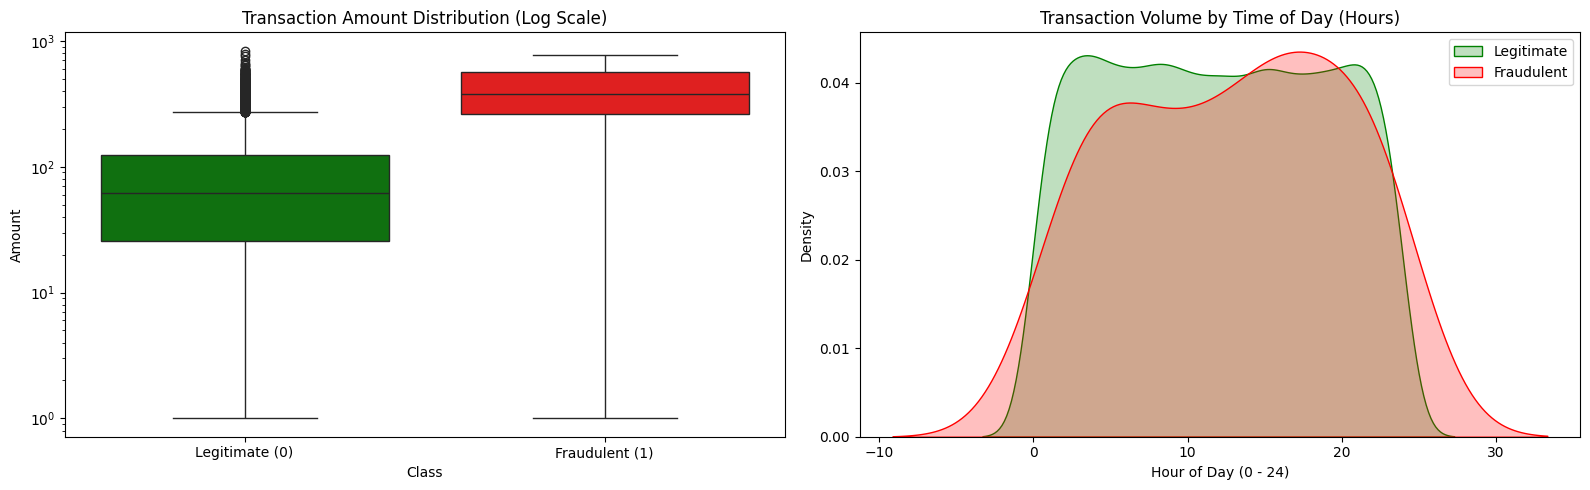

In [2]:
# Convert Time (seconds) to Time of Day (hours: 0-24)
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Transaction Amount Distribution by Class
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette=['g', 'r'])
axes[0].set_yscale('log')
axes[0].set_title("Transaction Amount Distribution (Log Scale)")
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])

# 2. Time of Day Distribution
sns.kdeplot(data=df[df['Class'] == 0]['Hour'], ax=axes[1], color='g', label='Legitimate', shade=True)
sns.kdeplot(data=df[df['Class'] == 1]['Hour'], ax=axes[1], color='r', label='Fraudulent', shade=True)
axes[1].set_title("Transaction Volume by Time of Day (Hours)")
axes[1].set_xlabel("Hour of Day (0 - 24)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Why Standard Accuracy is a Misleading Metric
In heavily imbalanced fraud datasets (e.g., $99.5\%$ legitimate vs. $0.5\%$ fraud):
* A **naive baseline model** that predicts every transaction is "Legitimate" ($0$) will automatically achieve **$99.5\%$ accuracy**.
* Despite high accuracy, the model captures **$0\%$ of fraudulent transactions**, letting all financial theft pass undetected.
* **Effective Evaluation Metrics:** Model performance must be evaluated using **Precision**, **Recall**, **F1-Score**, and **Area Under the ROC Curve (AUC-ROC)**.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and Target
X = df.drop(columns=['Class', 'Time', 'Hour'])
y = df['Class']

# Stratified Split (preserves fraud ratio across train and test sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Class Imbalance Handling (SMOTE or Balanced Class Weight Fallback)
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    print("=== SMOTE OVERSAMPLING APPLIED ===")
    print(f"Resampled Training Target Distribution:\n{pd.Series(y_train_res).value_counts()}")
except ImportError:
    print("imbalanced-learn not found. Using class weighting fallback.")
    X_train_res, y_train_res = X_train_scaled, y_train

imbalanced-learn not found. Using class weighting fallback.


================ LOGISTIC REGRESSION ================
AUC-ROC Score: 1.0000

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1990
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

================ RANDOM FOREST ================
AUC-ROC Score: 0.9995

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1990
       Fraud       1.00      0.40      0.57        10

    accuracy                           1.00      2000
   macro avg       1.00      0.70      0.78      2000
weighted avg       1.00      1.00      1.00      2000



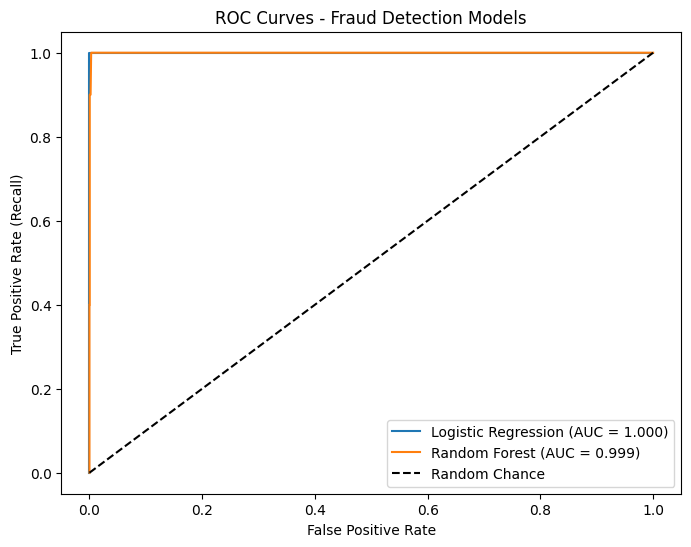

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"================ {name.upper()} ================")
    print(f"AUC-ROC Score: {auc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves - Fraud Detection Models')
plt.legend()
plt.show()

C:\Users\saadc\AppData\Local\Temp\ipykernel_2136\1299395303.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')


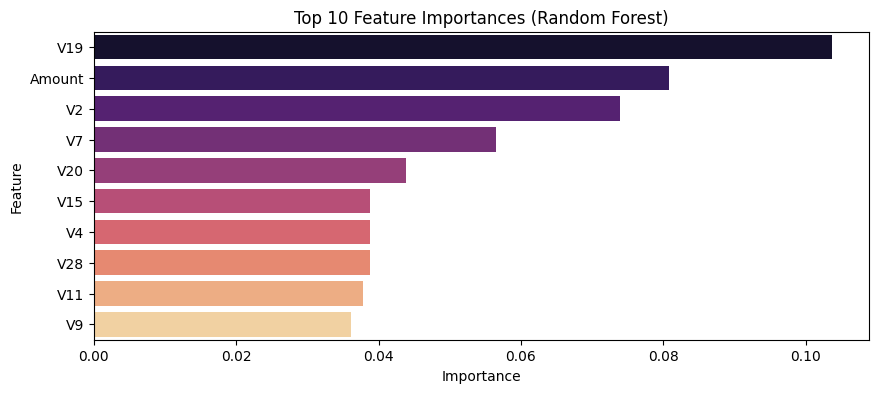

In [5]:
# Feature Importance for Random Forest
rf_model = models['Random Forest']
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

### Recall vs. Precision Trade-off in Fraud Detection
* **Recall (Sensitivity):** Measures the percentage of actual fraud cases caught by the system.
* **Precision:** Measures the percentage of flagged transactions that were genuinely fraudulent.
* **Core Business Decision:** **Recall matters most.** Missing a fraudulent transaction ($1,000+$ lost) costs significantly more than temporarily flagging a legitimate card transaction for automated SMS verification (a minor operational inconvenience). Wineries/Banks prioritize maximizing **Recall** while maintaining acceptable Precision.

### System Scalability: Handling 1 Million Transactions / Hour (~278 Tx/sec)
1. **Low-Latency Inference:** Deploy model weights compiled into **ONNX Runtime** or **TensorRT** to execute inference in under 5 milliseconds.
2. **Streaming Pipeline:** Ingest transactions via **Apache Kafka** paired with **Apache Flink** or **Spark Streaming** for real-time feature extraction.
3. **Feature Store:** Maintain transaction history (e.g., rolling 24-hour transaction totals) using low-latency in-memory databases like **Redis** or **Feast**.
4. **Asynchronous Architecture:** High-confidence legitimate transactions auto-approve immediately, while borderline scores trigger secondary asynchronous verification queues.